# Lesson 03 workbook — Segment and measure real pills

A real pill photograph becomes a clean mask, approximate physical dimensions, and a defensible measurement decision.

## Setup

Load the MEDISEG-Deploy image, class annotations, and published nominal reference lengths.

Repository: Official-Website-portfolio
Git branch: main
Lesson asset: lessons\2026-08-05\assets\03-mixed-pills.jpg
Results directory: results\lesson-03-workbook
NumPy: 2.5.1
OpenCV: 5.0.0


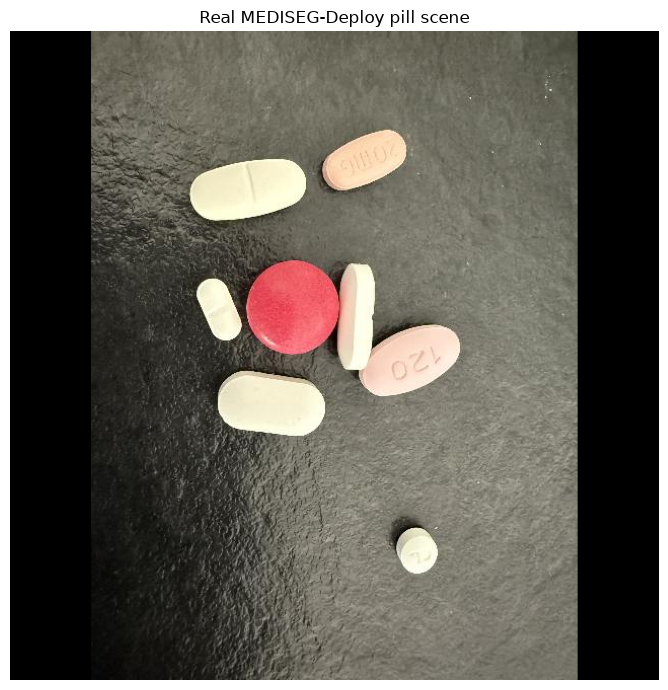

Saved: results\lesson-03-workbook\01-input.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-03-workbook/01-input.png')

In [15]:
RESULTS_NAME = "lesson-03-workbook"

from pathlib import Path
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError(
        "No Git repository root was found. Run the notebook inside the "
        "assigned repository."
    )


def find_lesson_asset(repo_root, filename):
    candidates = [
        Path.cwd() / "assets" / filename,
        repo_root
        / "program"
        / "labs"
        / "applied_computing_notebooks"
        / "03-segmentation-and-measurement"
        / "assets"
        / filename,
    ]
    lessons_root = repo_root / "lessons"
    if lessons_root.is_dir():
        candidates.extend(sorted(lessons_root.glob(f"*/assets/{filename}")))
    matches = []
    for candidate in candidates:
        if candidate.is_file() and candidate.resolve() not in matches:
            matches.append(candidate.resolve())
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {filename} lesson asset, found {len(matches)}: {matches}"
        )
    return matches[0]


def plot_image(axis, image, title, display="gray"):
    if display == "rgb":
        axis.imshow(image)
    else:
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(output_path, dpi=150, facecolor="white")
    plt.show()
    print("Saved:", output_path.relative_to(REPO_ROOT))
    return output_path


def component_count(mask):
    return int(cv2.connectedComponents(np.asarray(mask, dtype=np.uint8))[0] - 1)


def rotated_dimensions(contour):
    (_, _), (width_px, height_px), _ = cv2.minAreaRect(contour)
    major_px, minor_px = sorted((float(width_px), float(height_px)), reverse=True)
    return major_px, minor_px


def shape_descriptors(contour):
    area_px2 = float(cv2.contourArea(contour))
    perimeter_px = float(cv2.arcLength(contour, True))
    major_px, minor_px = rotated_dimensions(contour)
    if area_px2 <= 0 or perimeter_px <= 0 or minor_px <= 0:
        raise ValueError("Contour geometry must be positive")
    return {
        "area_px2": area_px2,
        "aspect_ratio": major_px / minor_px,
        "circularity": 4.0 * np.pi * area_px2 / perimeter_px**2,
        "equivalent_diameter_px": float(np.sqrt(4.0 * area_px2 / np.pi)),
        "rotated_major_px": major_px,
        "rotated_minor_px": minor_px,
    }


def select_measurement_method(aspect_ratio, circularity):
    if aspect_ratio <= 1.20 and circularity >= 0.75:
        return "round", "equivalent_diameter"
    return "elongated", "rotated_box"


def annotation_center(annotation):
    x, y, width, height = annotation["bbox"]
    return x + width / 2.0, y + height / 2.0


def annotation_figure(image_bgr, annotations):
    annotated = image_bgr.copy()
    rows = []
    for index, annotation in enumerate(annotations, start=1):
        x, y, width, height = annotation["bbox"]
        cv2.rectangle(
            annotated,
            (x, y),
            (x + width, y + height),
            (30, 180, 255),
            2,
        )
        cv2.putText(
            annotated,
            str(index),
            (x + 4, y + 17),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (20, 20, 20),
            3,
            cv2.LINE_AA,
        )
        cv2.putText(
            annotated,
            str(index),
            (x + 4, y + 17),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        rows.append([str(index), annotation["label"]])

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(11, 7),
        gridspec_kw={"width_ratios": [1.6, 1.0]},
    )
    plot_image(
        axes[0],
        cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        "Annotated pill scene",
        display="rgb",
    )
    axes[1].axis("off")
    axes[1].set_title("MEDISEG-Deploy labels")
    table = axes[1].table(
        cellText=rows,
        colLabels=["Region", "Dataset label"],
        colLoc="left",
        cellLoc="left",
        colWidths=[0.24, 0.70],
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.55)
    return figure


def measurement_figure(image_bgr, contours, records, pixels_per_mm):
    annotated = image_bgr.copy()
    rows = []
    for index, (contour, record) in enumerate(zip(contours, records), start=1):
        color = (40, 210, 40) if record["status"] == "isolated" else (30, 165, 255)
        cv2.drawContours(annotated, [contour], -1, color, 2)
        moments = cv2.moments(contour)
        center_x = int(moments["m10"] / moments["m00"])
        center_y = int(moments["m01"] / moments["m00"])
        cv2.circle(annotated, (center_x, center_y), 12, (25, 25, 25), -1)
        cv2.putText(
            annotated,
            str(index),
            (center_x - 5, center_y + 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        names = " + ".join(record["labels"]) or "unmatched"
        size = (
            f"{record['major_mm']:.1f} x {record['minor_mm']:.1f} mm"
            if record["status"] == "isolated"
            else "merged; no individual size"
        )
        method = {
            "equivalent_diameter": "equivalent diameter",
            "rotated_box": "rotated box",
            "not_measured": "rejected",
        }[record["method"]]
        rows.append([str(index), names, record["shape_class"], method, size])

    scale_length_px = int(round(10.0 * pixels_per_mm))
    scale_start = (36, 602)
    scale_end = (scale_start[0] + scale_length_px, scale_start[1])
    cv2.line(annotated, scale_start, scale_end, (255, 255, 255), 7)
    cv2.line(annotated, scale_start, scale_end, (25, 25, 25), 3)
    cv2.putText(
        annotated,
        "10 mm estimated",
        (scale_start[0], scale_start[1] - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.44,
        (255, 255, 255),
        3,
        cv2.LINE_AA,
    )
    cv2.putText(
        annotated,
        "10 mm estimated",
        (scale_start[0], scale_start[1] - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.44,
        (25, 25, 25),
        1,
        cv2.LINE_AA,
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        gridspec_kw={"width_ratios": [1.05, 1.35]},
    )
    plot_image(
        axes[0],
        cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        "Connected regions",
        display="rgb",
    )
    axes[1].axis("off")
    axes[1].set_title("Shape-aware physical measurements")
    table = axes[1].table(
        cellText=rows,
        colLabels=["Region", "Dataset label", "Shape", "Method", "Result"],
        colLoc="left",
        cellLoc="left",
        colWidths=[0.10, 0.34, 0.14, 0.20, 0.22],
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.55)
    return figure


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / RESULTS_NAME
if REPO_ROOT not in RESULTS_DIR.parents:
    raise RuntimeError("Results directory is outside the repository")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BRANCH = subprocess.run(
    ["git", "branch", "--show-current"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

ASSET_PATH = find_lesson_asset(REPO_ROOT, "03-mixed-pills.jpg")
scene_bgr = cv2.imread(str(ASSET_PATH), cv2.IMREAD_COLOR)
if scene_bgr is None:
    raise RuntimeError(f"OpenCV could not read the lesson asset: {ASSET_PATH}")
if scene_bgr.shape[:2] != (640, 640):
    raise RuntimeError(f"Unexpected lesson image shape: {scene_bgr.shape}")
scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)
scene_hsv = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2HSV)

PILL_ANNOTATIONS = [
    {"label": "Panadol", "bbox": (177, 126, 116, 62)},
    {"label": "Esomeprazole", "bbox": (309, 97, 84, 61)},
    {"label": "Fexofenadine", "bbox": (344, 290, 100, 71)},
    {"label": "Ibuprofen", "bbox": (235, 226, 91, 94)},
    {"label": "Paracetamol 1", "bbox": (322, 230, 38, 104)},
    {"label": "Paracetamol 2", "bbox": (205, 335, 107, 65)},
    {"label": "Cetirizine", "bbox": (185, 243, 45, 64)},
    {"label": "Loperamide", "bbox": (382, 490, 40, 45)},
]
NOMINAL_MAJOR_MM = {"Panadol": 17.0, "Cetirizine": 9.4}

print("Repository:", REPO_ROOT.name)
print("Git branch:", BRANCH or "(detached)")
print("Lesson asset:", ASSET_PATH.relative_to(REPO_ROOT))
print("Results directory:", RESULTS_DIR.relative_to(REPO_ROOT))
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

figure, axis = plt.subplots(figsize=(7, 7))
plot_image(axis, scene_rgb, "Real MEDISEG-Deploy pill scene", display="rgb")
save_figure(figure, "01-input.png")

## Exercise 1 — Reproduce Otsu thresholding

Implement the histogram calculation without calling `cv2.threshold`, then compare it with OpenCV on the real scene.

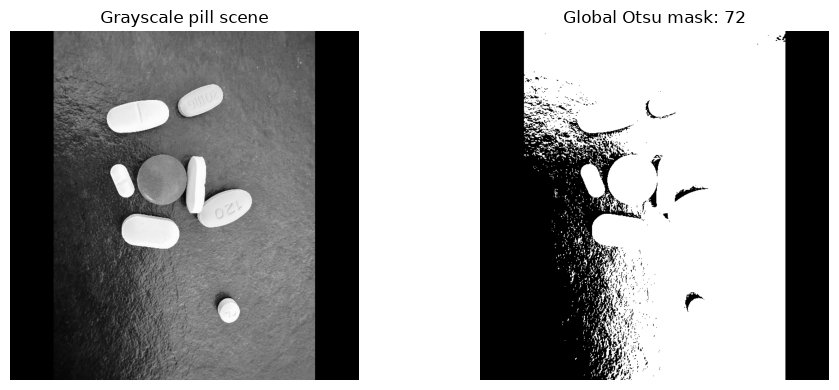

Saved: results\lesson-03-workbook\02-global-otsu-limit.png
PASS — Otsu threshold: 72


In [16]:
def otsu_threshold(gray):
    image = np.asarray(gray, dtype=np.uint8)
    counts, _ = np.histogram(image, bins=256, range=(0, 256))
    total = counts.sum()
    best_variance = 0
    best_threshold = 0
    for t in range(256):
        w0 = counts[:t + 1].sum() / total
        w1 = 1 - w0
        if w0 == 0 or w1 == 0:
            continue
        mu0 = sum(i * counts[i] for i in range(t + 1)) / (counts[:t + 1].sum())
        mu1 = sum(i * counts[i] for i in range(t + 1, 256)) / (counts[t + 1:].sum())
        variance = w0 * w1 * (mu0 - mu1) ** 2
        if variance > best_variance:
            best_variance = variance
            best_threshold = t
    return best_threshold
    raise NotImplementedError("Write otsu_threshold")


my_threshold = otsu_threshold(scene_gray)
reference_threshold, reference_mask = cv2.threshold(
    scene_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)
assert isinstance(my_threshold, (int, np.integer))
assert int(my_threshold) == int(reference_threshold)
otsu_mask = np.where(scene_gray > my_threshold, 255, 0).astype(np.uint8)
assert np.array_equal(otsu_mask, reference_mask)

figure, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_image(axes[0], scene_gray, "Grayscale pill scene")
plot_image(axes[1], otsu_mask, f"Global Otsu mask: {my_threshold}")
save_figure(figure, "02-global-otsu-limit.png")
print("PASS — Otsu threshold:", my_threshold)

## Exercise 2 — Keep differently colored pills

Create a binary candidate mask from the HSV value channel so white, pink, and red pills can share one brightness rule.

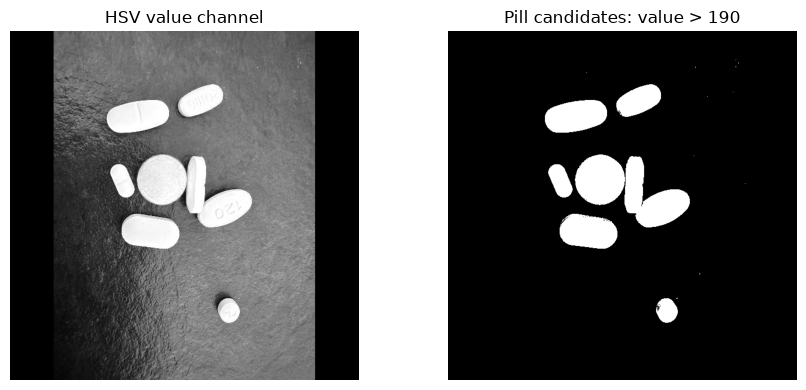

Saved: results\lesson-03-workbook\03-value-mask.png
PASS — candidate components: 20


In [17]:
def make_value_mask(image_bgr, minimum_value):
    image = np.asarray(image_bgr, dtype=np.uint8)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    value_channel = hsv[:, :, 2]
    mask = np.where(value_channel > minimum_value, 255, 0).astype(np.uint8)
    return mask
    raise NotImplementedError("Write make_value_mask")


candidate_mask = make_value_mask(scene_bgr, minimum_value=190)
assert candidate_mask.shape == scene_gray.shape
assert candidate_mask.dtype == np.uint8
assert set(np.unique(candidate_mask)) <= {0, 255}
assert component_count(candidate_mask) == 20

figure, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_image(axes[0], scene_hsv[:, :, 2], "HSV value channel")
plot_image(axes[1], candidate_mask, "Pill candidates: value > 190")
save_figure(figure, "03-value-mask.png")
print("PASS — candidate components:", component_count(candidate_mask))

## Exercise 3 — Clean without over-merging

Apply opening and closing with a 5 x 5 elliptical kernel. Retain the opened mask because closing merges an additional neighboring region.

20 7 6


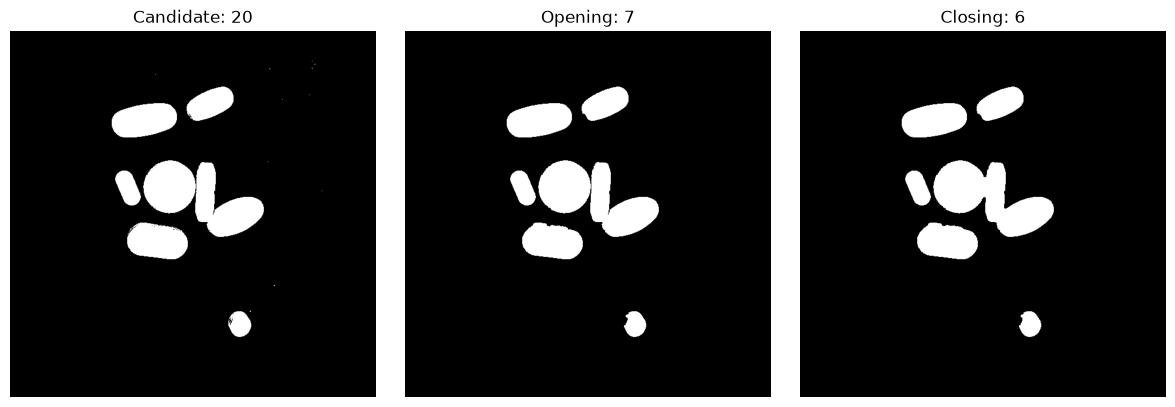

Saved: results\lesson-03-workbook\04-morphology.png
PASS — components: 20 7 6


In [20]:
def external_contours(mask, minimum_area=500):
    contours, _ = cv2.findContours(
        np.asarray(mask, dtype=np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    kept = [contour for contour in contours if cv2.contourArea(contour) >= minimum_area]
    kept.sort(key=lambda contour: cv2.boundingRect(contour)[1])
    return kept


def labels_in_contour(contour, annotations):
    labels = []
    for annotation in annotations:
        center = annotation_center(annotation)
        if cv2.pointPolygonTest(contour, center, False) >= 0:
            labels.append(annotation["label"])
    return labels

def clean_mask(mask):
    binary = np.asarray(mask, dtype=np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)
    return opening, closed

opened_mask, closed_mask = clean_mask(candidate_mask)
components_raw = component_count(candidate_mask)
components_opened = component_count(opened_mask)
components_closed = component_count(closed_mask)
print(components_raw, components_opened, components_closed)
assert (components_raw, components_opened, components_closed) == (20, 7, 6)


analysis_mask = opened_mask
region_contours = external_contours(analysis_mask)
assert len(region_contours) == 7

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_image(axes[0], candidate_mask, f"Candidate: {components_raw}")
plot_image(axes[1], opened_mask, f"Opening: {components_opened}")
plot_image(axes[2], closed_mask, f"Closing: {components_closed}")
save_figure(figure, "04-morphology.png")
print("PASS — components:", components_raw, components_opened, components_closed)

0: ['Esomeprazole']
1: ['Panadol']
2: ['Ibuprofen']
3: ['Fexofenadine', 'Paracetamol 1']
4: ['Cetirizine']
5: ['Paracetamol 2']
6: ['Loperamide']


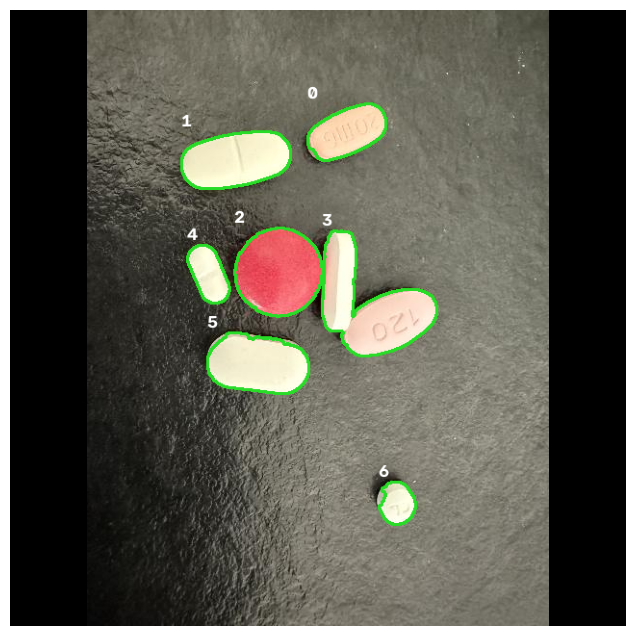

In [24]:
temp = scene_bgr.copy()
for i, c in enumerate(region_contours):
    cv2.drawContours(temp, [c], -1, (40, 220, 40), 2)
    x, y, _, _ = cv2.boundingRect(c)
    cv2.putText(temp, str(i), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    labels = labels_in_contour(c, PILL_ANNOTATIONS)
    print(f"{i}: {labels}")
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Exercise 4 — Calibrate and measure by shape

Match contours to annotation centers, require agreement between two scale references, then use circularity and aspect ratio to select each isolated pill's measurement method automatically.

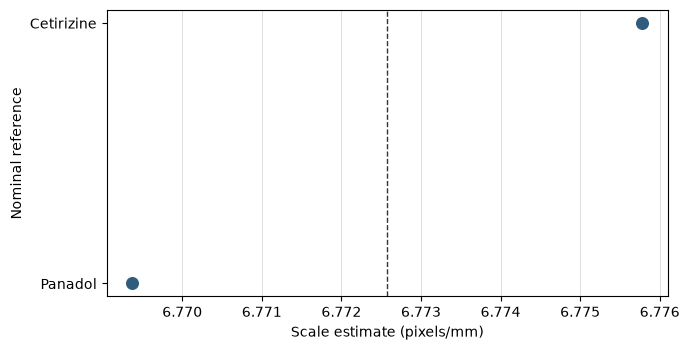

Saved: results\lesson-03-workbook\05-reference-calibration.png


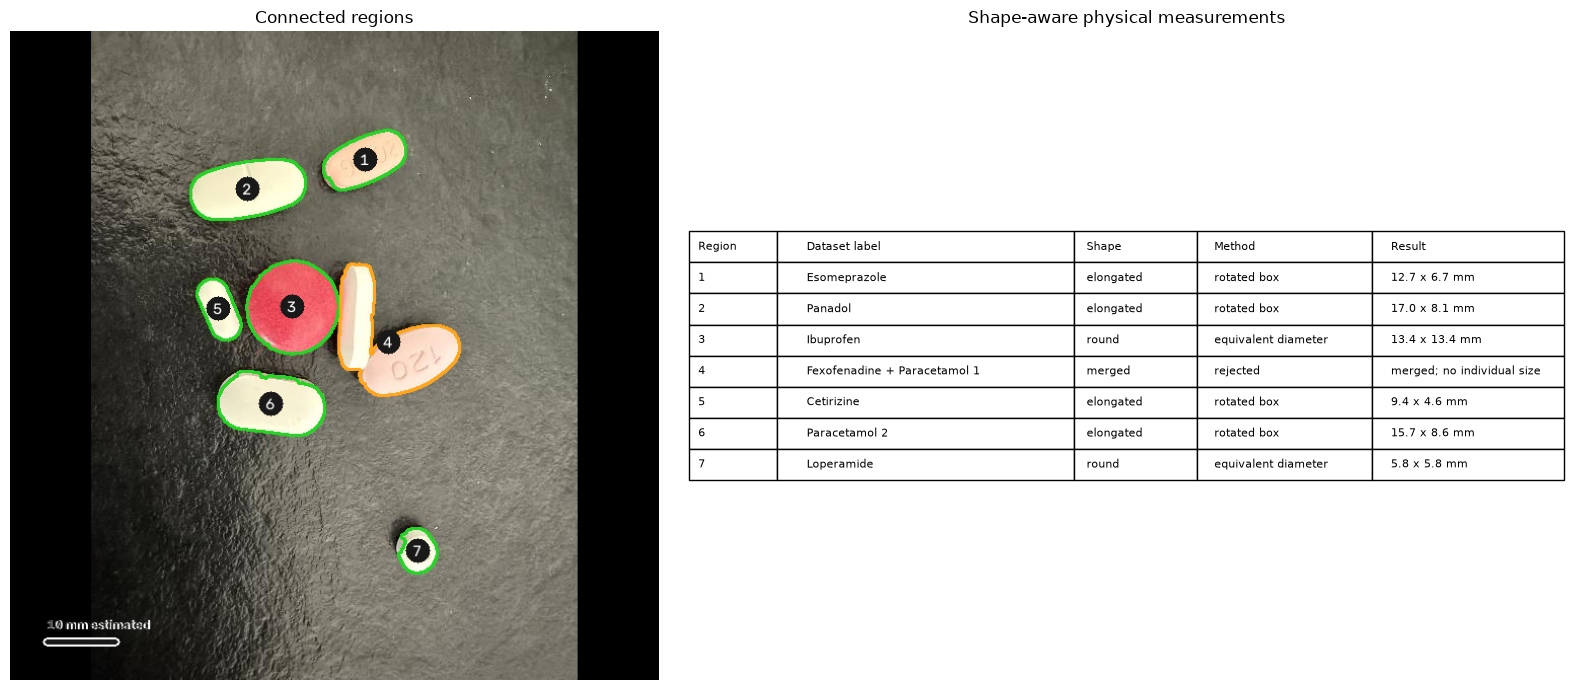

Saved: results\lesson-03-workbook\06-estimated-measurements.png
PASS — pixels/mm: 6.7726
Reference spread: 0.095%


In [32]:
def contour_for_label(contours, annotations, label):
    annotation = next(item for item in annotations if item["label"] == label)
    center = annotation_center(annotation)
    matches = [c for c in contours if cv2.pointPolygonTest(c, center, False) >= 0]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one contour for {label}, found {len(matches)}")
    return matches[0]


def calibration_scales(contours, annotations, nominal_major_mm):
    scales = {}
    for label, major_mm in nominal_major_mm.items():
        contour = contour_for_label(contours, annotations, label)
        major_px, _ = rotated_dimensions(contour)
        scales[label] = major_px / float(major_mm)
    return scales


def measure_regions(contours, annotations, pixels_per_mm):
    if pixels_per_mm <= 0:
        raise ValueError("pixels_per_mm must be positive")
    records = []
    for contour in contours:
        labels = labels_in_contour(contour, annotations)
        descriptors = shape_descriptors(contour)
        status = "isolated" if len(labels) == 1 else "merged"
        if status == "isolated":
            shape_class, method = select_measurement_method(
                descriptors["aspect_ratio"],
                descriptors["circularity"],
            )
            if method == "equivalent_diameter":
                major_px = descriptors["equivalent_diameter_px"]
                minor_px = major_px
            else:
                major_px = descriptors["rotated_major_px"]
                minor_px = descriptors["rotated_minor_px"]
            major_mm = major_px / pixels_per_mm
            minor_mm = minor_px / pixels_per_mm
        else:
            shape_class = "merged"
            method = "not_measured"
            major_px = None
            minor_px = None
            major_mm = None
            minor_mm = None
        records.append({
            "labels": labels,
            "status": status,
            "shape_class": shape_class,
            "method": method,
            "aspect_ratio": descriptors["aspect_ratio"],
            "circularity": descriptors["circularity"],
            "major_px": major_px,
            "minor_px": minor_px,
            "major_mm": major_mm,
            "minor_mm": minor_mm,
            "area_mm2": descriptors["area_px2"] / pixels_per_mm**2,
        })
    return records


reference_scales = calibration_scales(
    region_contours,
    PILL_ANNOTATIONS,
    NOMINAL_MAJOR_MM,
)
assert set(reference_scales) == set(NOMINAL_MAJOR_MM)
pixels_per_mm = float(np.median(list(reference_scales.values())))
relative_spread = (
    max(reference_scales.values()) - min(reference_scales.values())
) / pixels_per_mm
assert 6.7 < pixels_per_mm < 6.9
assert relative_spread < 0.02

measurements = measure_regions(region_contours, PILL_ANNOTATIONS, pixels_per_mm)
assert len(measurements) == 7
assert sum(record["status"] == "isolated" for record in measurements) == 6
assert sum(record["status"] == "merged" for record in measurements) == 1
assert sum(record["method"] == "equivalent_diameter" for record in measurements) == 2
assert sum(record["method"] == "rotated_box" for record in measurements) == 4
assert sum(record["method"] == "not_measured" for record in measurements) == 1
assert {
    record["labels"][0]
    for record in measurements
    if record["method"] == "equivalent_diameter"
} == {"Ibuprofen", "Loperamide"}
for record in measurements:
    assert 0 < record["circularity"] <= 1
    assert record["aspect_ratio"] >= 1
    if record["status"] != "isolated":
        assert record["major_mm"] is None and record["minor_mm"] is None
        continue
    assert record["major_mm"] >= record["minor_mm"] > 0

figure, axis = plt.subplots(figsize=(7, 3.6))
labels = list(reference_scales)
values = [reference_scales[label] for label in labels]
axis.scatter(values, labels, s=70, color="#315b7d")
axis.axvline(pixels_per_mm, color="#333333", linewidth=1, linestyle="--")
axis.set(xlabel="Scale estimate (pixels/mm)", ylabel="Nominal reference")
axis.grid(axis="x", color="#dddddd", linewidth=0.7)
save_figure(figure, "05-reference-calibration.png")

figure = measurement_figure(
    scene_bgr,
    region_contours,
    measurements,
    pixels_per_mm,
)
save_figure(figure, "06-estimated-measurements.png")
print("PASS — pixels/mm:", round(pixels_per_mm, 4))
print("Reference spread:", f"{100 * relative_spread:.3f}%")

## Open problem — Audit a measurement choice

Select one connected region, inspect the automatic shape classification, then accept it or test an alternative axis-aligned box, rotated box, or equivalent diameter. Explain whether the region represents one pill.

CAUTION — this contour contains multiple labeled pills: ['Fexofenadine', 'Paracetamol 1']


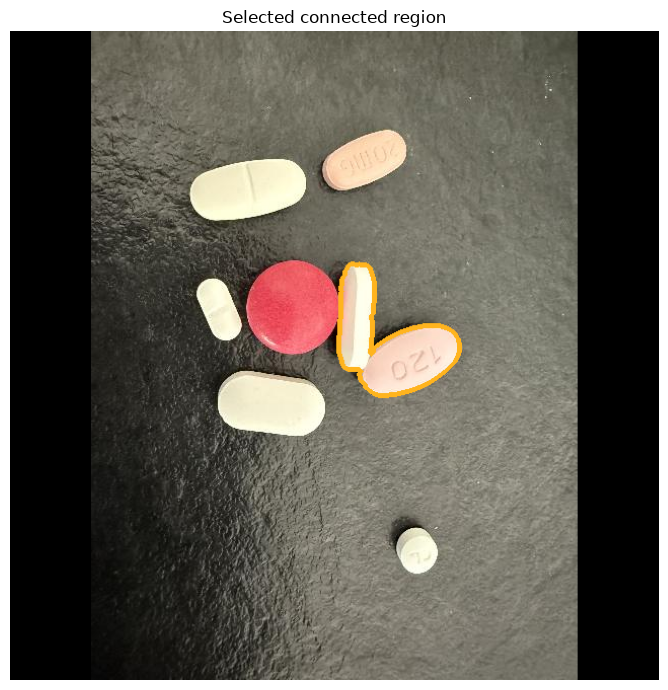

Saved: results\lesson-03-workbook\07-measurement-decision.png
PASS — labels: ['Fexofenadine', 'Paracetamol 1']
Decision measurement: {'major': 20.87222851668144, 'minor': 14.299437286518364, 'units': 'mm', 'method': 'rotated_box'}


In [33]:
def measure_for_decision(contour, pixels_per_mm, calibration_accepted, method):
    area = float(cv2.contourArea(contour))
    units = "mm" if calibration_accepted else "px"
    if method == "equivalent_diameter":
        major = float(np.sqrt(4.0 * area / np.pi))
        minor = major
    elif method == "rotated_box":
        major, minor = rotated_dimensions(contour)
    elif method == "axis_aligned":
        x, y, w, h = cv2.boundingRect(contour)
        major, minor = (float(w), float(h)) if w >= h else (float(h), float(w))
    if calibration_accepted:
        major, minor = major / pixels_per_mm, minor / pixels_per_mm
    return {"major": major, "minor": minor, "units": units, "method": method}


selected_region_index = 3
calibration_accepted = True
selected_method = "rotated_box"
decision_reason = "This contour contains two merged pills so individual measurement is not valid, but rotated box was selected because the merged region is elongated with an aspect ratio above 1.2 making it the correct method for the shape even though the result does not represent one pill alone."


if selected_region_index is None:
    raise RuntimeError("Select a connected-region index")
if not isinstance(selected_region_index, (int, np.integer)):
    raise TypeError("The connected-region index must be an integer")
if not 0 <= selected_region_index < len(region_contours):
    raise ValueError("The connected-region index is outside the contour list")
if not isinstance(calibration_accepted, (bool, np.bool_)):
    raise TypeError("Record whether the nominal calibration is accepted")
if selected_method not in {"axis_aligned", "rotated_box", "equivalent_diameter"}:
    raise ValueError("Select axis_aligned, rotated_box, or equivalent_diameter")
if len(decision_reason.split()) < 20:
    raise RuntimeError("Explain the decision in at least 20 words")

selected_contour = region_contours[selected_region_index]
selected_labels = labels_in_contour(selected_contour, PILL_ANNOTATIONS)
decision_measurement = measure_for_decision(
    selected_contour,
    pixels_per_mm=pixels_per_mm,
    calibration_accepted=calibration_accepted,
    method=selected_method,
)
assert {"major", "minor", "units", "method"} <= set(decision_measurement)
assert decision_measurement["major"] >= decision_measurement["minor"] > 0
assert decision_measurement["units"] == ("mm" if calibration_accepted else "px")
assert decision_measurement["method"] == selected_method
if len(selected_labels) != 1:
    print("CAUTION — this contour contains multiple labeled pills:", selected_labels)

decision_image = scene_bgr.copy()
cv2.drawContours(decision_image, [selected_contour], -1, (30, 180, 255), 3)
figure, axis = plt.subplots(figsize=(7, 7))
plot_image(
    axis,
    cv2.cvtColor(decision_image, cv2.COLOR_BGR2RGB),
    "Selected connected region",
    display="rgb",
)
save_figure(figure, "07-measurement-decision.png")

summary_lines = [
    f"pixels_per_mm={pixels_per_mm:.6f}",
    f"reference_relative_spread={relative_spread:.6f}",
    f"selected_labels={'+'.join(selected_labels)}",
    f"calibration_accepted={calibration_accepted}",
    f"measurement_method={selected_method}",
    f"measurement_major={decision_measurement['major']:.6f}",
    f"measurement_minor={decision_measurement['minor']:.6f}",
    f"measurement_units={decision_measurement['units']}",
    f"decision_reason={decision_reason.strip()}",
]
(RESULTS_DIR / "measurements.txt").write_text(
    "\n".join(summary_lines) + "\n",
    encoding="utf-8",
)
print("PASS — labels:", selected_labels)
print("Decision measurement:", decision_measurement)

## Questions

1. Why does global grayscale Otsu thresholding include part of the background?

   **Answer:** It can't differntitate bright spots in the background from foreground (target).

2. Why does the HSV value channel retain both white and red pills?

   **Answer:** The pills have equal brigthness-or similar-whichc auses the algorithm to not differentiate them and retain them.

3. Why can closing reduce the connected-region count too far?

   **Answer:** It dilates first then erodes-the dilation amplifies the connected region which erode fails to erase properly resulting in lower connected-region counts.

4. Why must independent nominal references produce similar pixels-per-millimeter values?

   **Answer:** This validates that each nominal reference's code worked correctly and nothing is wrong-a small variance indicates precision and accurate conversion.

5. Why does the measurement rule use equivalent diameter for round pills, rotated boxes for elongated pills, and no individual size for a merged region?

   **Answer:** Round pills are circular so an equivalent diameter measurement uses an equivalent circle's area to fill the pill's silhouette. Rotated boxes work for elongated pill sbecause they rotate to surround the silhouette of the pill and form a bounding box around it. Merged pills form a blob-this prevents accurate individual measurement regardless of the measurement method used.

Complete every answer, then commit the executed workbook and `results/lesson-03-workbook/`, then push.

Sources: [MEDISEG dataset](https://city.figshare.com/articles/dataset/MEDISEG/28574786) · [OpenCV thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html) · [OpenCV morphology](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html) · [Panadol nominal length](https://dailymed.nlm.nih.gov/dailymed/getFile.cfm?name=PANADOL+EXTRA+STRENGTH&setid=b2fe7f47-1a2e-40ee-8f8f-38f2028dce1b) · [Cetirizine nominal dimensions](https://www.medicines.org.uk/emc/product/12956/smpc)